## Refrigeracion

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [35]:
#import csv

import os
# Definición de ruta
file_path =  '../../data/raw/fridge_fault_timeseries_dataset.csv' #https://www.kaggle.com/datasets/samoilovmikhail/simulated-refrigerator-fault-diagnosis-dataset?resource=download
#other for ULT refrigerators: https://lab.compute.dtu.dk/taohu/ult-freezers-labelled-dataset-sci-data/-/tree/main/data/dataset?ref_type=heads
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")

print(df.head())
#df.isna().sum()
df.describe()

Dataset cargado exitosamente. Formato: (1872000, 21)
       T_amb     T_set      T_cab  T_evap_sat  T_cond_sat  P_suc_bar  \
0  22.187599  2.627537  22.111991   18.162151   30.019587   4.964200   
1  22.372591  2.627537  21.962171   18.119603   30.427325   4.905156   
2  22.328321  2.627537  21.838008   17.999535   30.270884   4.875609   
3  22.614706  2.627537  21.775435   18.109126   30.685874   4.895076   
4  22.428984  2.627537  21.661756   17.692930   30.322264   4.876375   

   P_dis_bar  N_comp_Hz      SH_K  P_comp_W  ...  COP  frost_level  \
0   7.322867       87.0  6.476948     600.0  ...  5.0     0.084003   
1   7.531698       87.0  6.021818     600.0  ...  5.0     0.083803   
2   7.408313       87.0  5.971117     600.0  ...  5.0     0.083603   
3   7.418943       87.0  6.002439     600.0  ...  5.0     0.083403   
4   7.507421       87.0  6.119263     600.0  ...  5.0     0.083203   

   T_cab_meas  valve_open  time_min  run_id   fault fault_id  door_open  \
0   22.251928    0

,T_amb,T_set,T_cab,T_evap_sat,T_cond_sat,P_suc_bar,P_dis_bar,N_comp_Hz,SH_K,P_comp_W,Q_evap_W,COP,frost_level,T_cab_meas,valve_open,time_min,run_id,fault_id,door_open,defrost_on
count,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06
mean,2.502810e+01,3.220848e+00,2.131217e+01,1.613717e+01,3.326359e+01,4.957957e+00,8.185168e+00,7.650492e+01,7.297271e+00,5.178258e+02,3.888621e+02,4.641907e+00,6.018202e-02,2.131302e+01,4.610819e-01,7.195000e+02,6.495000e+02,6.000000e+00,4.831944e-02,3.399145e-02
std,5.234617e+00,1.021385e+00,7.061757e+00,1.327970e+01,5.649930e+00,1.461210e+00,1.505371e+00,1.805654e+01,1.958237e+00,1.591568e+02,3.855537e+02,1.108437e+00,2.377869e-01,7.077854e+00,5.874712e-02,4.156922e+02,3.752777e+02,3.741658e+00,2.144404e-01,1.812072e-01
min,1.093664e+01,1.506844e+00,-1.686483e+00,-4.536191e+01,1.618393e+01,4.695570e-01,4.493195e+00,0.000000e+00,4.522527e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.667282e+00,2.293190e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.126294e+01,2.298816e+00,1.762674e+01,1.400686e+01,2.922573e+01,4.329147e+00,7.067831e+00,7.483404e+01,5.942414e+00,4.555741e+02,0.000000e+00,5.000000e+00,0.000000e+00,1.762915e+01,4.244928e-01,3.597500e+02,3.247500e+02,3.000000e+00,0.000000e+00,0.000000e+00
50%,2.499133e+01,3.215166e+00,2.081207e+01,1.738082e+01,3.320422e+01,4.828974e+00,8.035276e+00,8.279456e+01,6.282454e+00,5.371618e+02,3.562177e+02,5.000000e+00,0.000000e+00,2.074392e+01,4.915264e-01,7.195000e+02,6.495000e+02,6.000000e+00,0.000000e+00,0.000000e+00
75%,2.878534e+01,4.104362e+00,2.555930e+01,2.259967e+01,3.725473e+01,5.711263e+00,9.157249e+00,8.700000e+01,8.516908e+00,5.916144e+02,6.081197e+02,5.000000e+00,0.000000e+00,2.562239e+01,5.017276e-01,1.079250e+03,9.742500e+02,9.000000e+00,0.000000e+00,0.000000e+00
max,3.924128e+01,4.998877e+00,4.332525e+01,4.283289e+01,5.141683e+01,1.097812e+01,1.450918e+01,8.700000e+01,1.502270e+01,1.743657e+03,2.656341e+03,5.000000e+00,1.200000e+00,4.332275e+01,5.443242e-01,1.439000e+03,1.299000e+03,1.200000e+01,1.000000e+00,1.000000e+00


TARGET: FAULT 

NORMAL: The refrigerator is operating correctly.

COND_FOUL_MILD / COND_FOUL_SEVERE: Simulates a clogged or dirty condenser, reducing its ability to reject heat.

EVAP_FAN_DEG / EVAP_FAN_FAIL: Degraded or failed evaporator fan, reducing internal air circulation and heat absorption.

UNDERCHARGE_MILD / UNDERCHARGE_SEVERE: Low refrigerant level, leading to poor performance and high superheat.

OVERCHARGE: Excess refrigerant, leading to high pressures and potential compressor damage.

SENSOR_DRIFT_PLUS / SENSOR_DRIFT_MINUS: The main cabinet temperature sensor gives an incorrect reading, causing the control system to work improperly.

COMP_INEFFICIENCY: A worn-out compressor that is less efficient at pumping refrigerant.

NON_CONDENSABLES: Air or other non-condensable gases trapped in the system, hindering condensation.

UNDERCHARGE_AND_COND_FOUL: A combined fault, representing a more complex real-world scenario.


T_amb: Ambient air temperature surrounding the refrigerator.

T_set: Temperature setpoint configured for the refrigerator.

T_cab: Internal cabinet air temperature (controller value).

T_evap_sat: Saturation temperature at the evaporator, derived from suction pressure.

T_cond_sat: Saturation temperature at the condenser, derived from discharge pressure.

P_suc_bar: Compressor suction pressure, in bar.

P_dis_bar: Compressor discharge pressure, in bar.

N_comp_Hz: Compressor operating speed or frequency, in hertz.

SH_K: Refrigerant superheat at the evaporator outlet, in kelvin.

P_comp_W: Electrical power consumption of the compressor, in watts.

Q_evap_W: Cooling capacity (heat absorbed) at the evaporator, in watts.

COP: Coefficient of performance, ratio of cooling capacity to compressor power.

frost_level: Estimated level of frost or ice accumulation on the evaporator.

T_cab_meas: Measured internal cabinet temperature from the sensor.

valve_open: Opening percentage or position of the expansion valve.

time_min: Elapsed operating time, in minutes.

run_id: Identifier for a continuous operating run or cycle.

fault_id: Identifier or label of the detected operating condition or fault.

door_open: Indicator showing whether the cabinet door is open.

defrost_on: Indicator showing whether the defrost cycle is active.

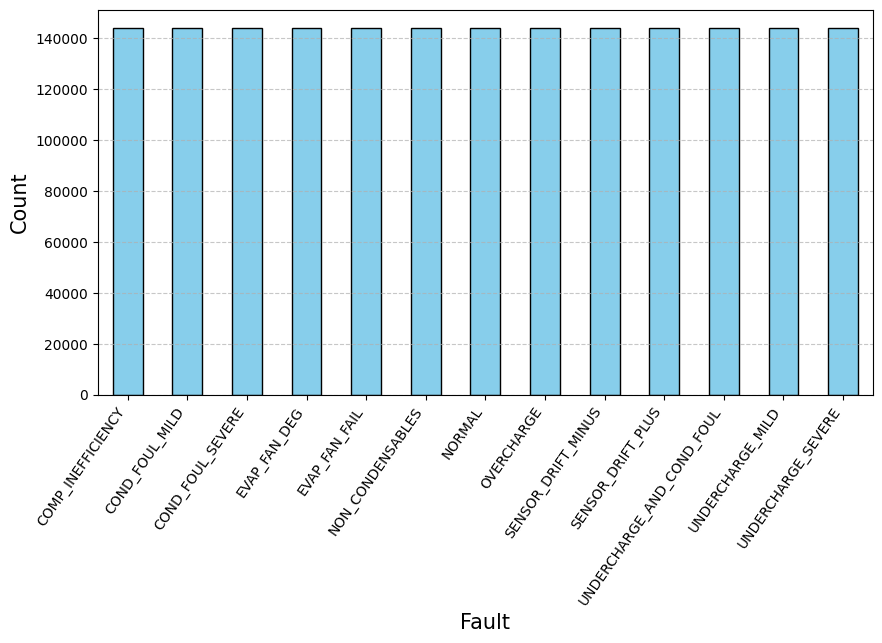

In [36]:
plt.figure(figsize=(10, 5))
df['fault'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=55, ha='right', fontsize=10)
plt.xlabel('Fault', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Feature correlation, only for fault_id

#Faults distribution


--- Ranking de Correlación Lineal con fault_id ---
run_id         9.970373e-01
P_suc_bar      2.902774e-01
T_cab          2.822508e-01
T_cab_meas     2.754378e-01
T_evap_sat     2.420213e-01
N_comp_Hz      1.230735e-01
COP            8.109866e-02
SH_K           8.065474e-02
P_dis_bar      2.281681e-02
T_cond_sat     2.211456e-02
T_set          1.464454e-02
T_amb          5.037400e-03
defrost_on     6.011451e-04
door_open      2.030595e-04
time_min      -1.239084e-14
valve_open    -8.065474e-02
frost_level   -1.216957e-01
P_comp_W      -1.600303e-01
Q_evap_W      -2.878640e-01
Name: fault_id, dtype: float64


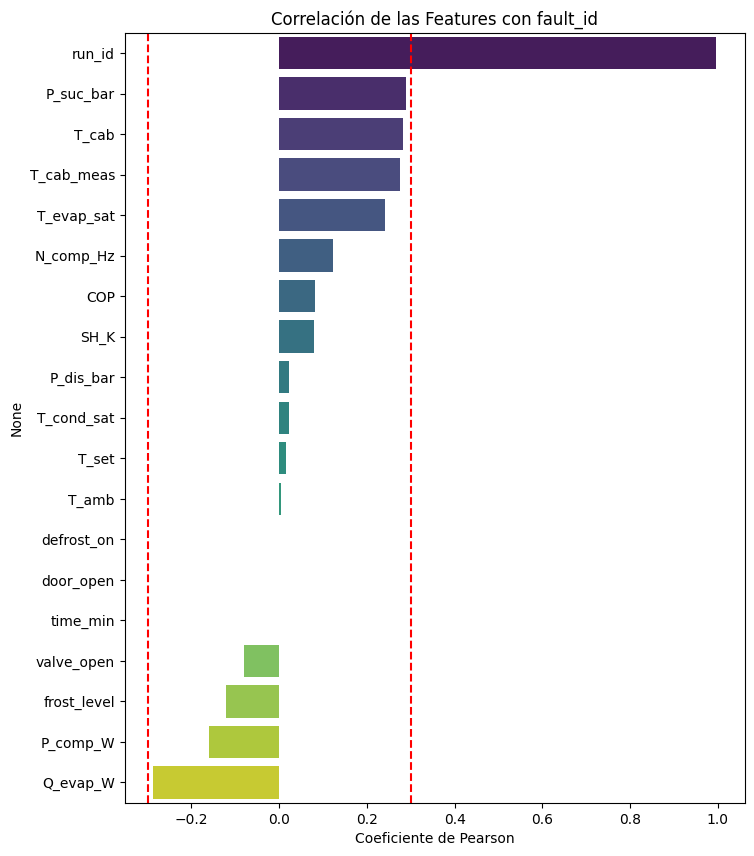

In [37]:
# 1. Calcular la matriz de correlación solo para números
corr_matrix = df.select_dtypes(include='number').corr()

# 2. Extraer la correlación de todas las columnas con 'fault_id'
# Usamos .abs() porque una correlación de -0.8 es tan importante como una de +0.8
fault_corr = corr_matrix['fault_id'].drop('fault_id').sort_values(ascending=False)

# 3. Mostrar el ranking
print("--- Ranking de Correlación Lineal con fault_id ---")
print(fault_corr)

# 4. (Opcional) Visualización rápida del ranking
plt.figure(figsize=(8, 10))
sns.barplot(x=fault_corr.values, y=fault_corr.index, hue=fault_corr.index, palette='viridis', legend=False)
plt.title('Correlación de las Features con fault_id')
plt.xlabel('Coeficiente de Pearson')
plt.axvline(x=0.3, color='r', linestyle='--', label='Umbral 0.3')
plt.axvline(x=-0.3, color='r', linestyle='--')
plt.show()

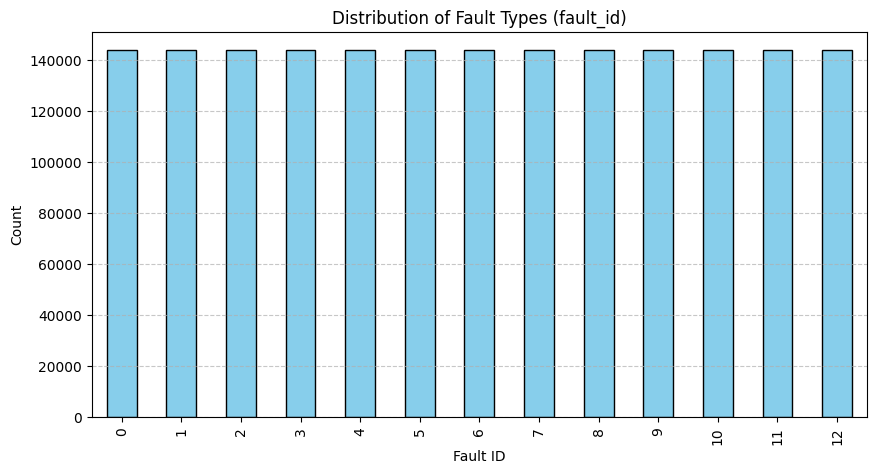

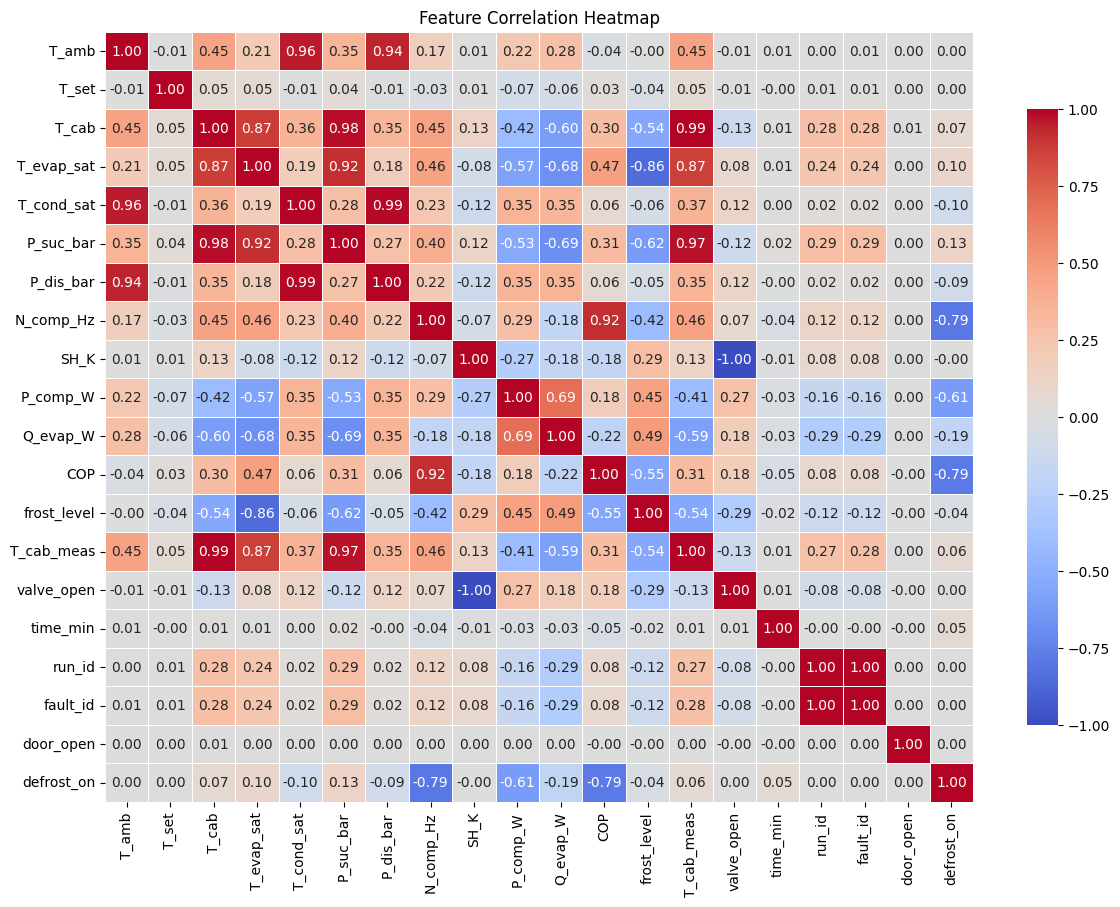

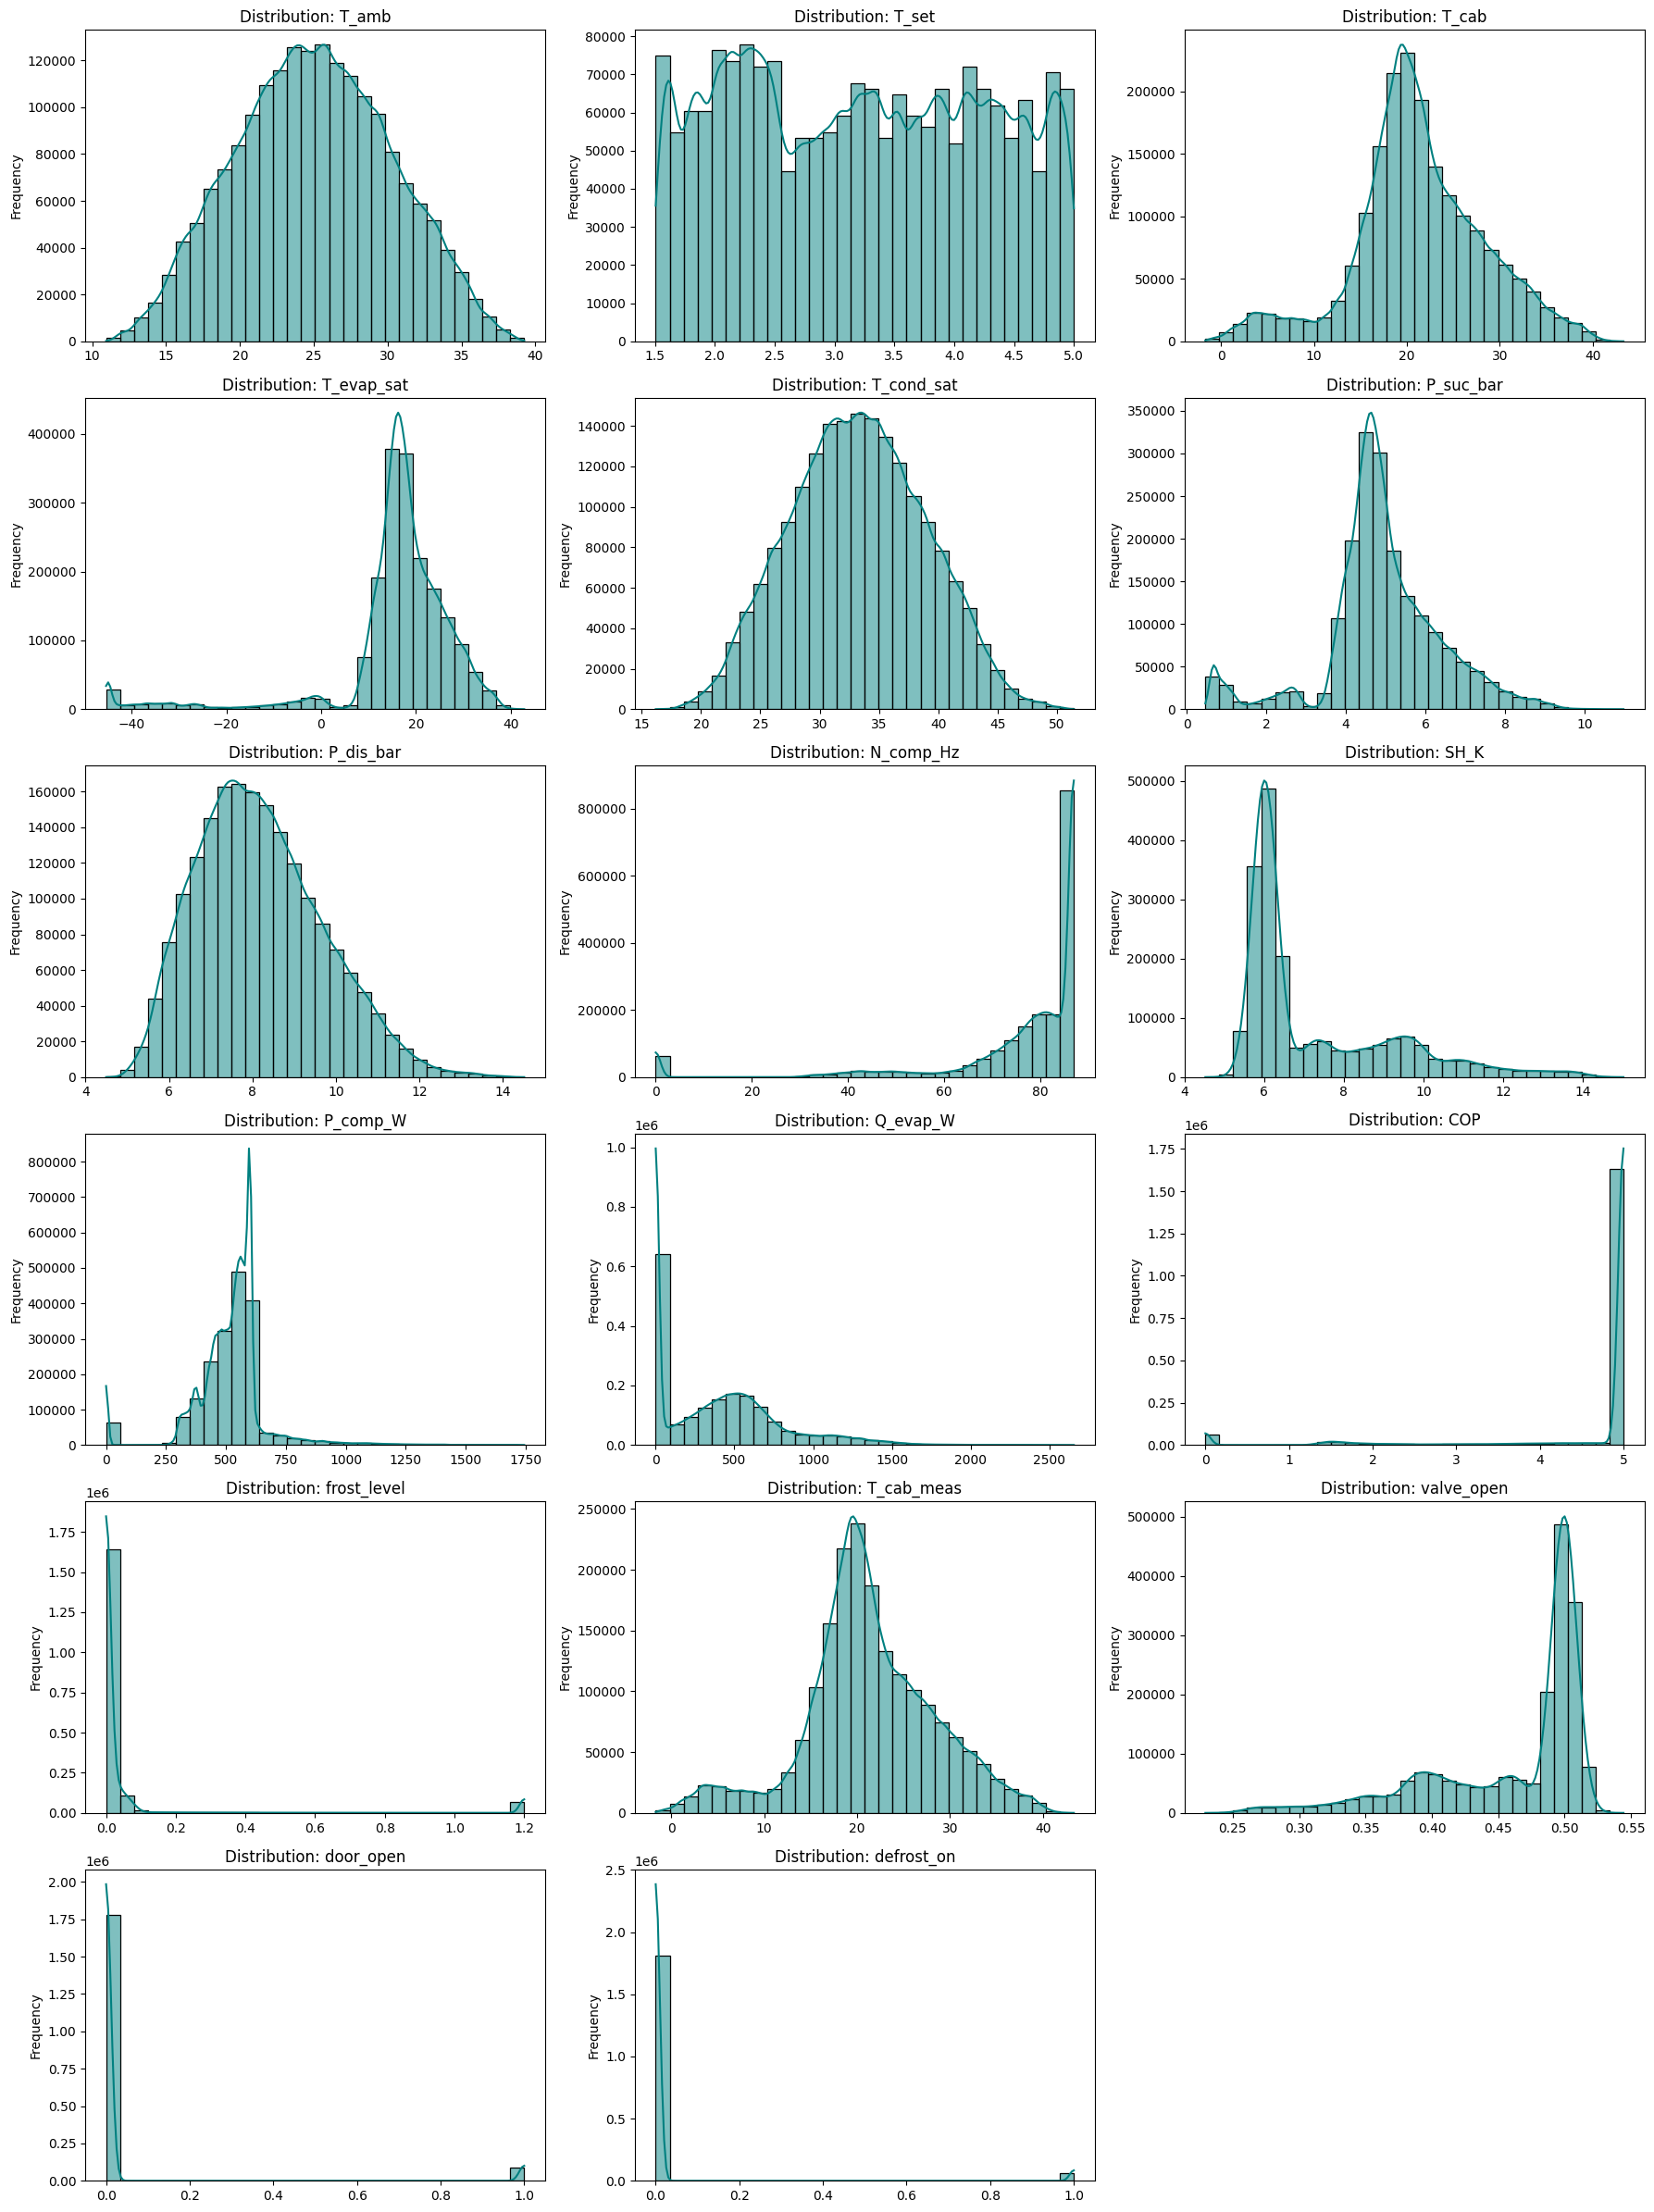

Analysis complete for 17 numerical features.


In [38]:
import math

#Faults distribution
plt.figure(figsize=(10, 5))
df['fault_id'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Fault Types (fault_id)')
plt.xlabel('Fault ID')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Correlation Heatmap
plt.figure(figsize=(14, 10))

core_cols = df.select_dtypes(include='number').columns
corr = df[core_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap')
plt.show()


exclude = ['run_id', 'time_min', 'fault_id', 'fault']
numerical_features = [c for c in df.select_dtypes(include='number').columns if c not in exclude]


num_features = len(numerical_features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution: {feature}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print(f"Analysis complete for {num_features} numerical features.")

In [39]:
import plotly.express as px

faults_to_compare = ['NORMAL', 'COND_FOUL_SEVERE', 'UNDERCHARGE_SEVERE', 'SENSOR_DRIFT_PLUS']

run_ids_to_plot = [df[df['fault'] == f]['run_id'].iloc[0] for f in faults_to_compare]

df_fault_comparison = df[df['run_id'].isin(run_ids_to_plot)]

fig = px.line(df_fault_comparison, x='time_min', y='T_cab', color='fault',
              title='Cabinet Temperature (T_cab) under Different Faults',
              labels={'T_cab': 'Cabinet Temp (°C)', 'time_min': 'Time (minutes)'})
fig.show()

fig = px.line(df_fault_comparison, x='time_min', y='P_comp_W', color='fault',
              title='Compressor Power (P_comp_W) under Different Faults',
              labels={'P_comp_W': 'Power (W)', 'time_min': 'Time (minutes)'})
fig.show()

fig = px.line(df_fault_comparison, x='time_min', y='SH_K', color='fault',
              title='Superheat (SH_K) under Different Faults',
              labels={'SH_K': 'Superheat (K)', 'time_min': 'Time (minutes)'})
fig.show()

fig = px.line(df_fault_comparison, x='time_min', y=['T_cond_sat', 'T_evap_sat'], color='fault',
              facet_row='variable', height=600,
              title='Saturation Temperatures under Different Faults',
              labels={'value': 'Temperature (°C)', 'time_min': 'Time (minutes)'})
fig.update_yaxes(matches=None)
fig.show()

In [40]:
# Some new features based on domain knowledge

def extract_physics_features(df):
    # Diferenciales térmicos
    df['T_error'] = df['T_cab'] - df['T_set']
    df['T_lift'] = df['T_cond_sat'] - df['T_evap_sat']
    # Si el condensador está sucio, la temperatura de saturación (T_cond_sat) se aleja mucho de la ambiente
    df['T_cond_approach'] = df['T_cond_sat'] - df['T_amb'] 
    df['T_spread'] = df['T_cond_sat'] - df['T_evap_sat']
    df['T_cab_meas_diff'] = df['T_cab'] - df['T_cab_meas'] 

    # Presiones y potencia
    df['P_ratio'] = df['P_dis_bar'] / (df['P_suc_bar'] + 0.1)
    df['Power_per_diff'] = df['P_comp_W'] / (df['T_lift'] + 0.1)

    # Eficiencia de transferencia: Vatios consumidos por cada grado de enfriamiento
    df['Q_est'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 1e-5)

    # Error de sensor 
    df['Sensor_error'] = df['T_cab'] - df['T_cab_meas'] 
    
    # Derivadas (Tendencias instantáneas)
    df['T_cab_grad'] = df.groupby('run_id')['T_cab'].diff().fillna(0)
    df['P_suc_rate'] = df.groupby('run_id')['P_suc_bar'].diff().fillna(0)

    df['Eff_vol'] = (df['T_evap_sat'] + 273.15) / (df['T_cond_sat'] + 273.15)
    df['P_suc_norm'] = df['P_suc_bar'] / df['T_amb']

    # Desviación de saturación (Crucial para detectar Aire/Incondensables - Clase 11)
    df['P_dis_error'] = df['P_dis_bar'] - (df['T_cond_sat'] * 0.25)

    # Diferencial de Subenfriamiento aproximado
    df['T_subcooling_approx'] = df['T_cond_sat'] - df['T_amb'] 
    # Relación Potencia-Presión
    df['Power_to_Pratio'] = df['P_comp_W'] / (df['P_ratio'] + 0.1)

    # Estabilidad de presión
    df['P_dis_volatility'] = df.groupby('run_id')['P_dis_bar'].transform(lambda x: x.rolling(window=5).std()).fillna(0)

    df["pressure_ratio"] = df["P_dis_bar"] / (df["P_suc_bar"] + 0.1)
    df["specific_work"] = df["P_comp_W"] / (df["Q_evap_W"]+ 0.1)
    df["cop_degradation"] = df["COP"] / df.groupby("run_id")["COP"].transform("max")

    # --- NUEVAS VARIABLES CRÍTICAS (PREDICTIVE) ---
    # Índice de eficiencia energética: relación entre el esfuerzo eléctrico y la capacidad de absorber calor
    df['EEI'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 0.1)
    # Carga térmica relativa (basada en inercia de producto si aplica)
    df['Thermal_Load_Index'] = (df['T_cab'] - df['T_evap_sat']) * df['P_ratio']

    return df

# Aplicar extracción
df = extract_physics_features(df)
df = df.sort_values(["run_id", "time_min"])

def create_lag_features(df, features, lags):
    for feature in features:
        for lag in lags:
            df[f"{feature}_lag_{lag}"] = (
                df.groupby("run_id")[feature]
                  .shift(lag)
            )
            df[f"{feature}_delta_{lag}"] = (
                df[feature] - df[f"{feature}_lag_{lag}"]
            )
    return df

# Ampliamos lag_features con variables de diagnóstico experto
lag_features = ["P_dis_bar", "T_cond_sat"]
# Lags: 5 (inestabilidad), 15 (tendencia media), 45 (deriva térmica lenta de suciedad)
lags = [5, 15, 45]

df = create_lag_features(df, lag_features, lags)

# Mantenemos tu lag largo pero ajustado a una ventana más realista para el predictivo
df['P_dis_error_lag_100'] = df.groupby("run_id")["P_dis_error"].shift(100)

def create_rolling_features(df, features, windows):
    for feature in features:
        for w in windows:
            roll = (
                df.groupby("run_id")[feature]
                  .rolling(w, min_periods=w//2)
            )
            df[f"{feature}_roll_std_{w}"] = df.groupby("run_id")[feature].transform(lambda x: x.rolling(w, min_periods=w//2).std())
            df[f"{feature}_roll_mean_{w}"] = roll.mean().reset_index(level=0, drop=True)
    return df

rolling_features = ["P_dis_bar", "T_cond_sat", "EEI"]
windows = [15, 30]

df = create_rolling_features(df, rolling_features, windows)

# Estabilidad refinada de presión
df["P_dis_bar_roll_std_20"] = (
    df.groupby("run_id")["P_dis_bar"]
      .rolling(20, min_periods=10)
      .std()
      .reset_index(level=0, drop=True)
)

df["P_dis_bar_roll_mean_20"] = (
    df.groupby("run_id")["P_dis_bar"]
      .rolling(20, min_periods=10)
      .mean()
      .reset_index(level=0, drop=True)
)

df["Pdis_instability_20"] = df["P_dis_bar_roll_std_20"] / (df["P_dis_bar_roll_mean_20"] + 1e-5)

# Inestabilidad en la transferencia térmica (Condensador)
df["cond_approach_std_20"] = (
    df.groupby("run_id")["T_cond_approach"]
      .rolling(20, min_periods=10)
      .std()
      .reset_index(level=0, drop=True)
)

# Limpieza final de NaNs generados por los nuevos lags
df = df.dropna(subset=[
    "Pdis_instability_20",
    "P_dis_bar_delta_15"
])

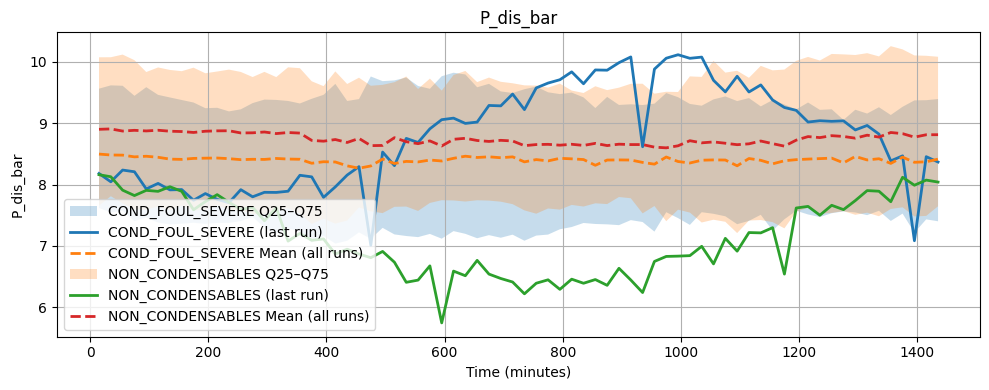

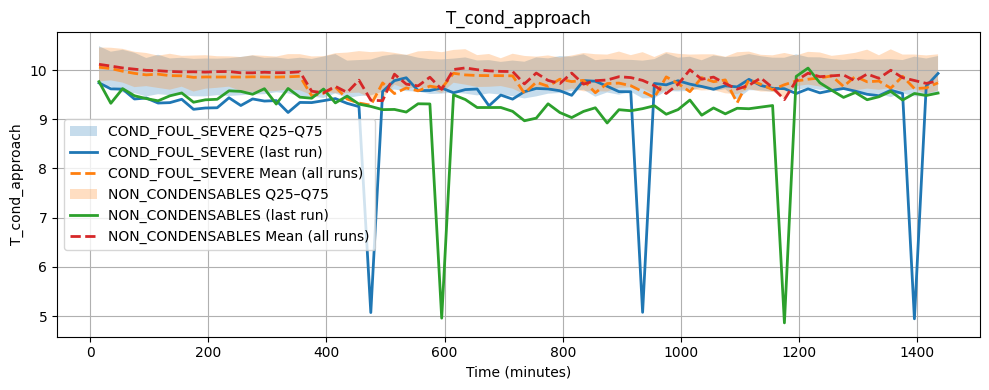

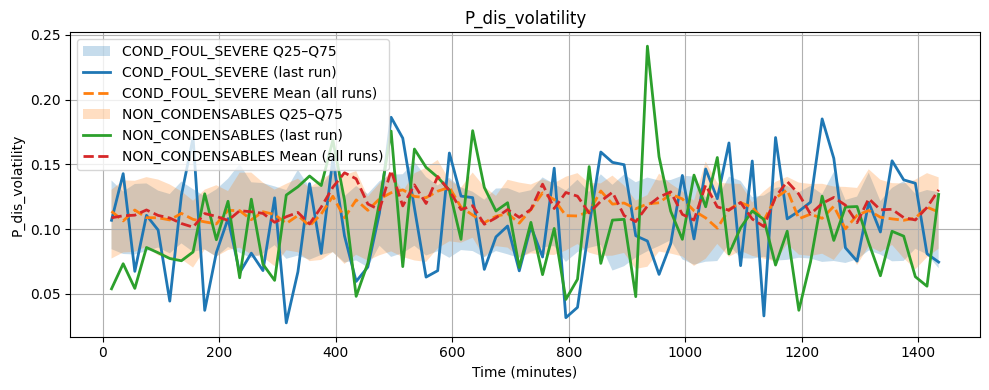

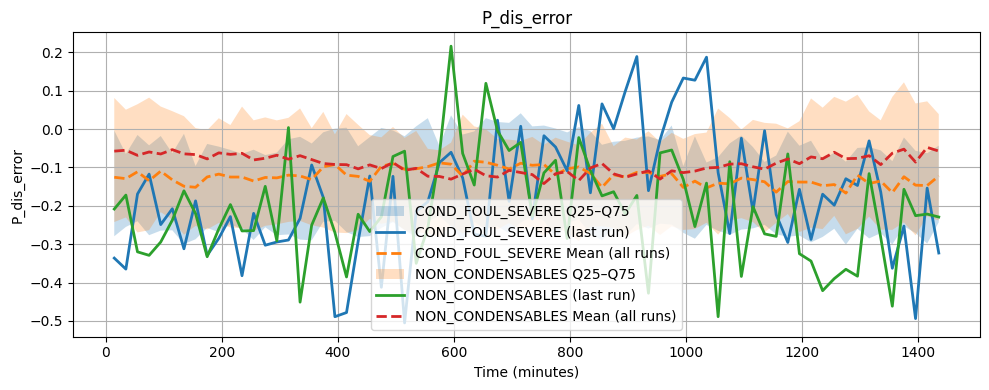

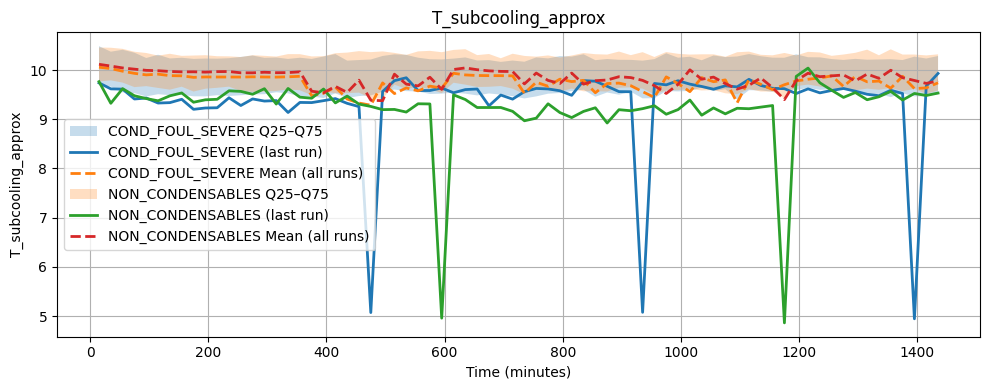

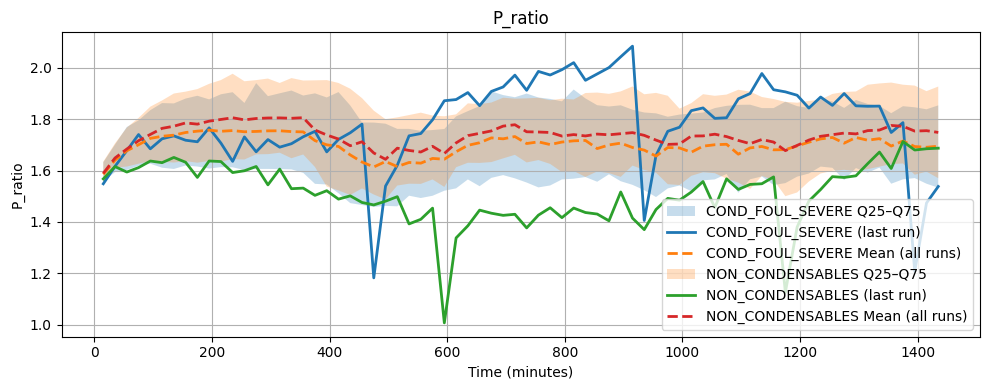

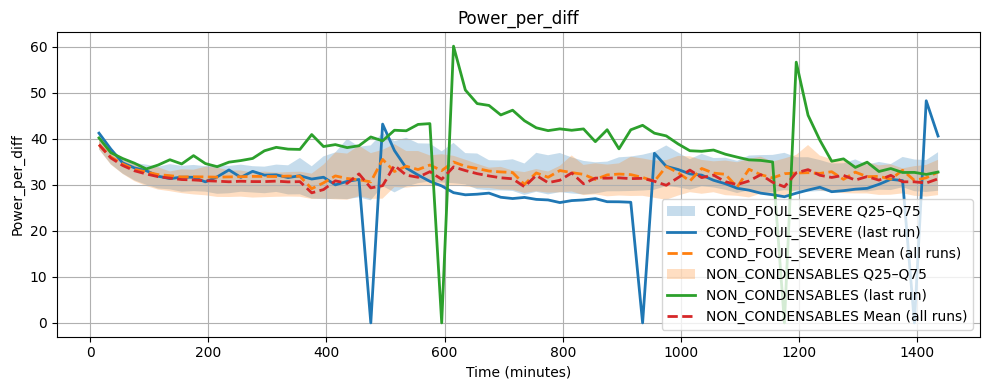

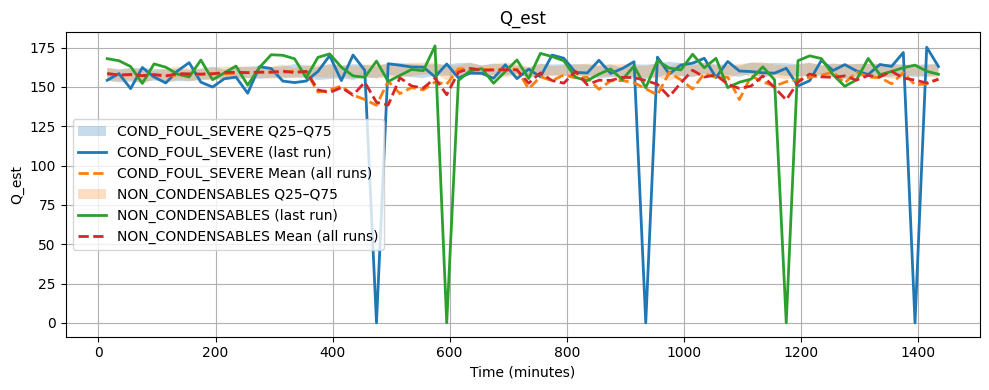

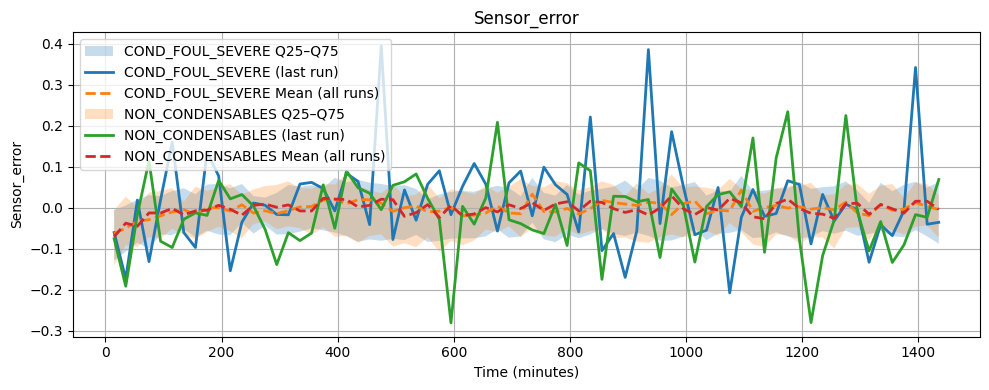

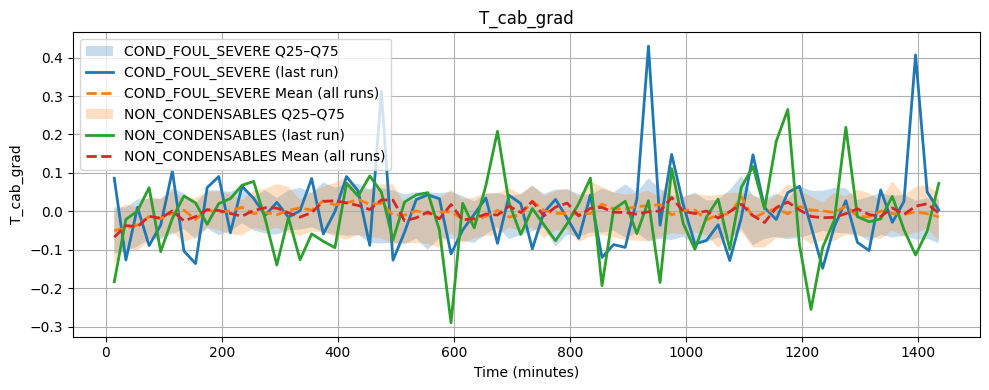

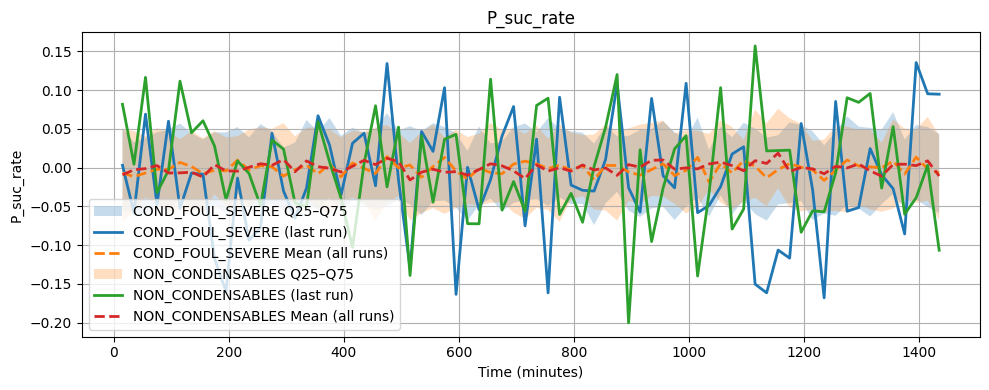

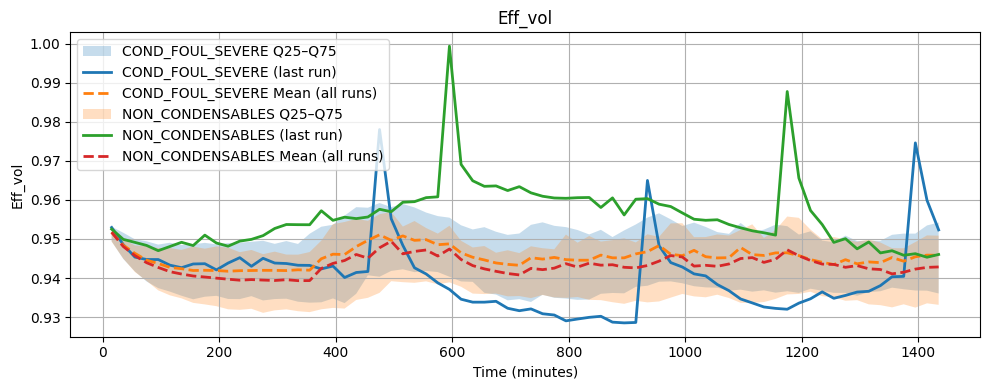

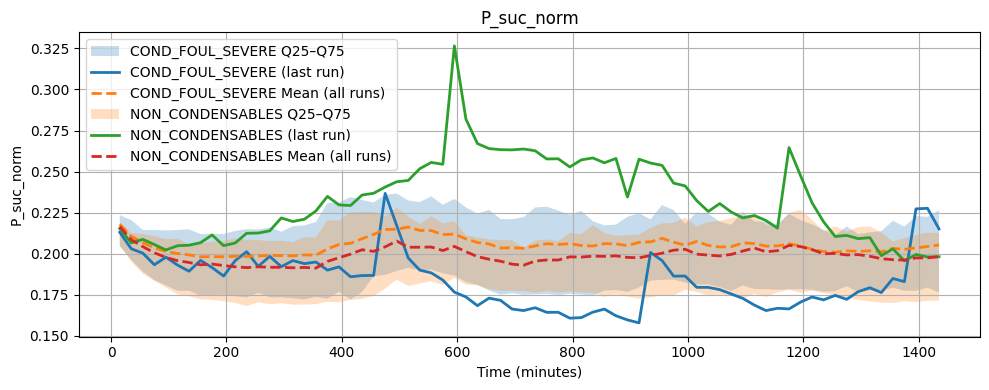

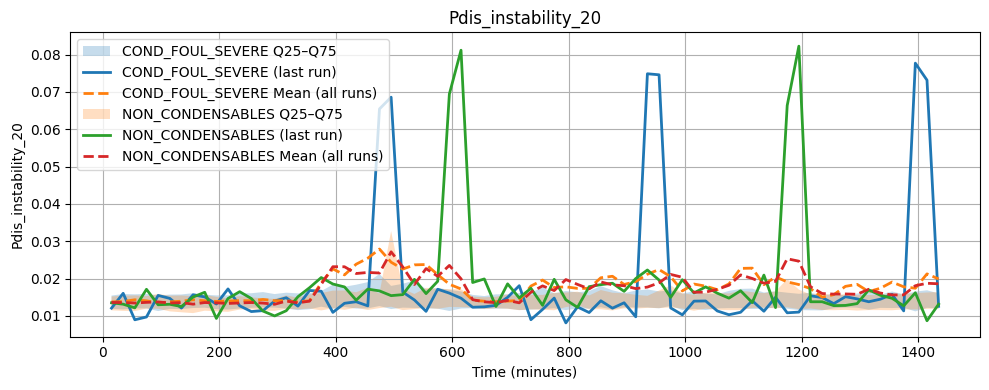

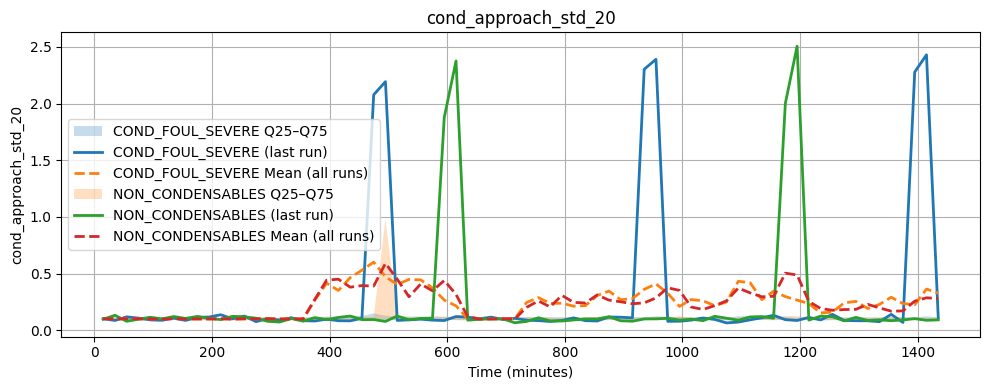

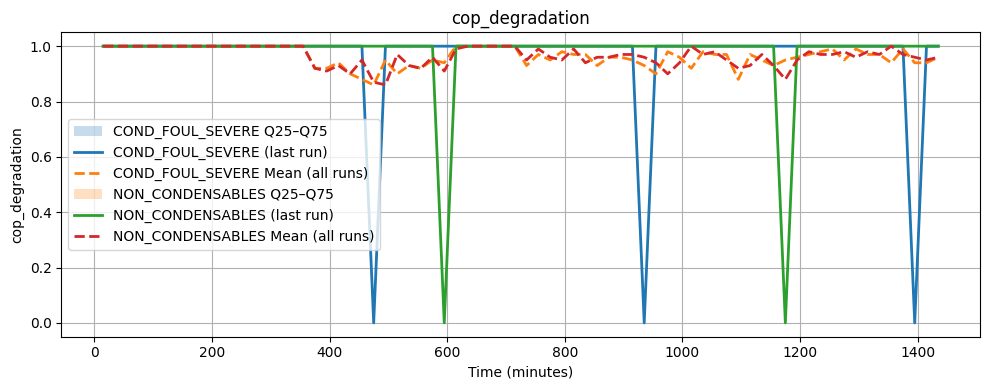

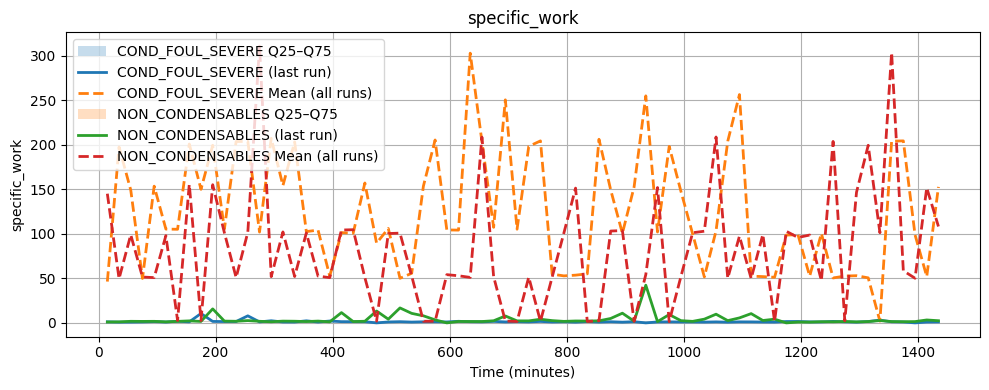

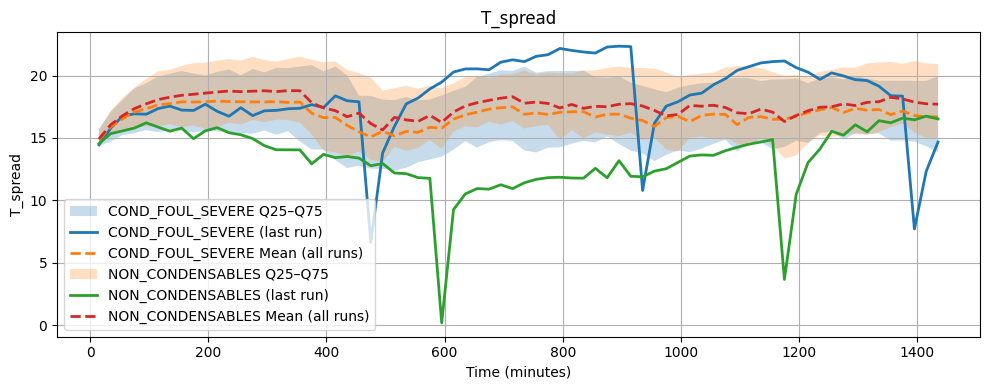

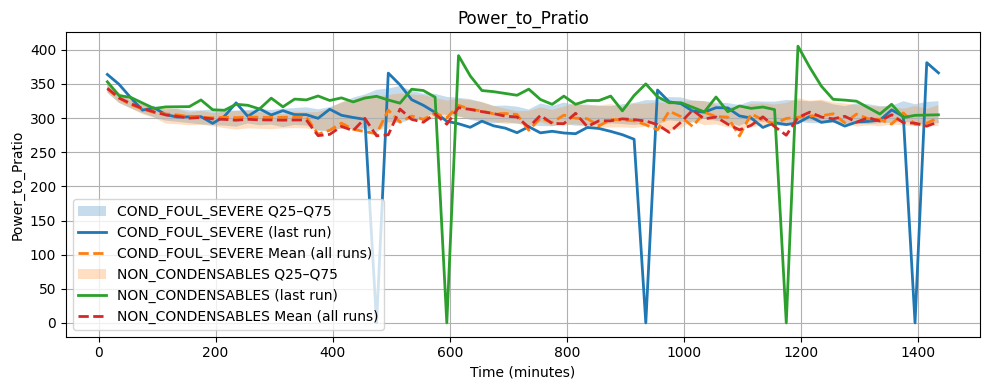

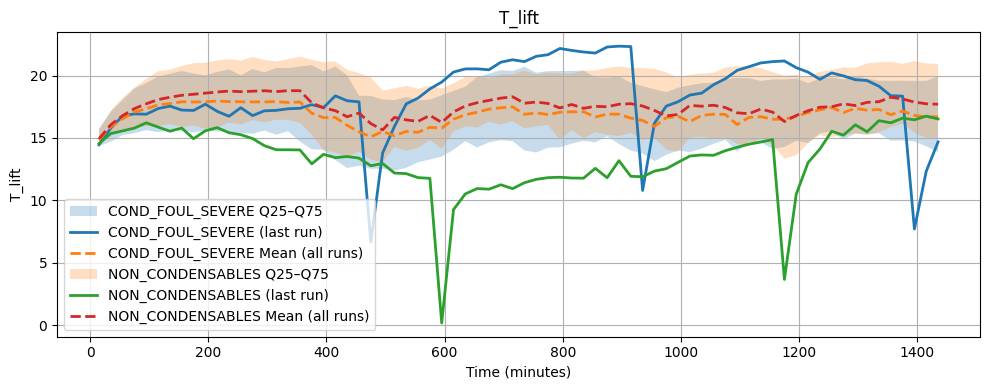


Mean values:
                  P_dis_bar  T_cond_approach  P_dis_volatility  P_dis_error  \
fault_name                                                                    
COND_FOUL_SEVERE   8.399866         9.744002          0.115112    -0.124466   
NON_CONDENSABLES   8.743838         9.827299          0.116853    -0.091288   

                  T_subcooling_approx   P_ratio  Power_per_diff       Q_est  \
fault_name                                                                    
COND_FOUL_SEVERE             9.744002  1.699405       32.349192  154.516589   
NON_CONDENSABLES             9.827299  1.737009       31.431728  154.726380   

                  Sensor_error  T_cab_grad  P_suc_rate   Eff_vol  P_suc_norm  \
fault_name                                                                     
COND_FOUL_SEVERE     -0.001823   -0.001755   -0.000263  0.945295    0.204892   
NON_CONDENSABLES     -0.002578   -0.002418   -0.000405  0.943318    0.198614   

                  Pdis_instabil

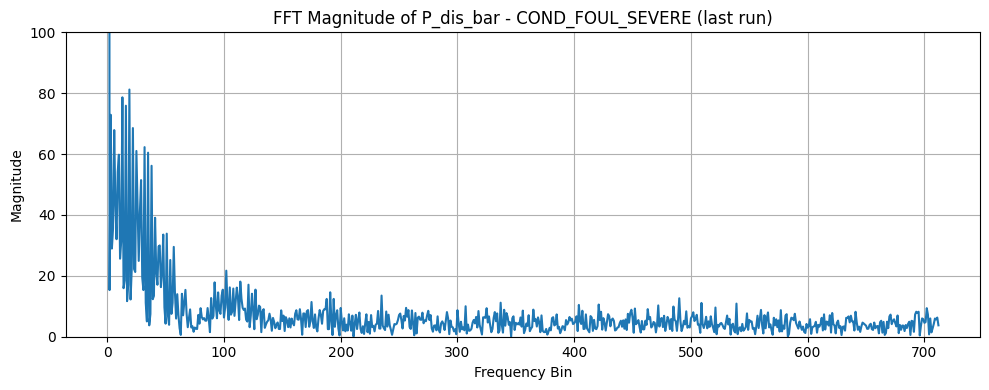

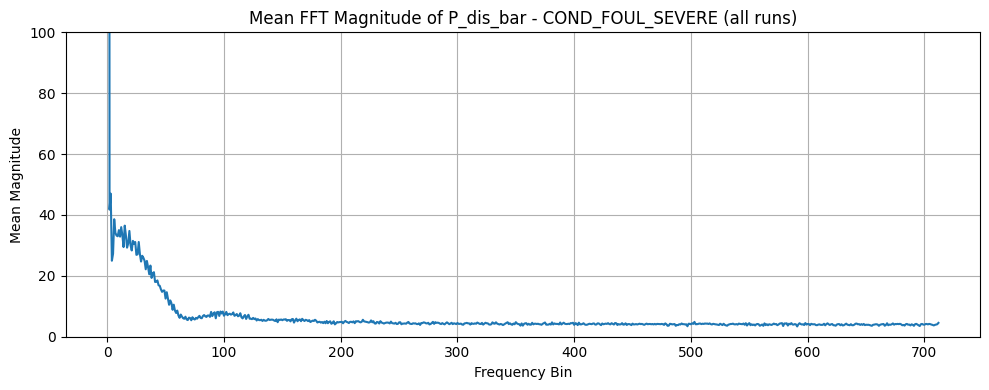

NON_CONDENSABLES: FFT shape = (713,)


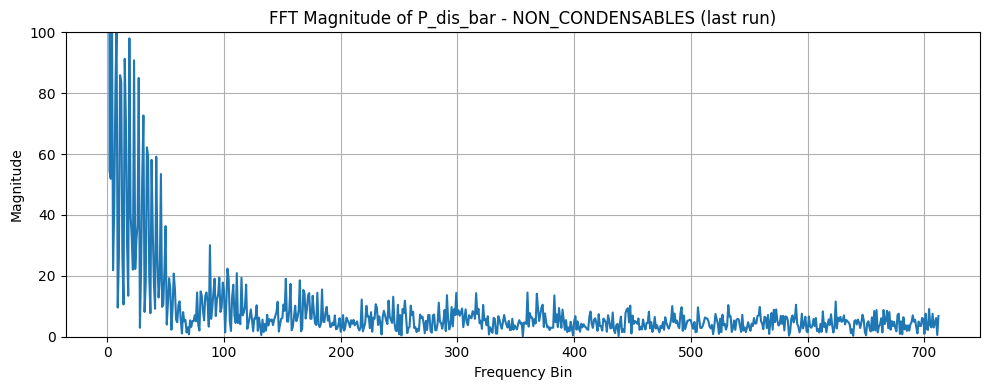

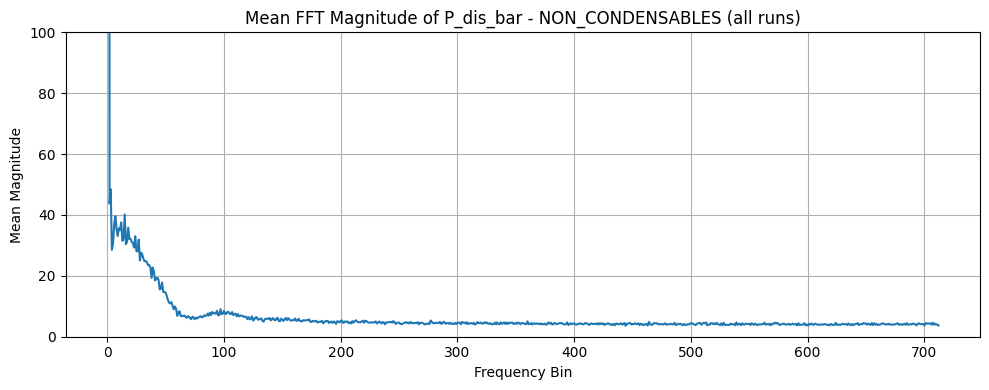

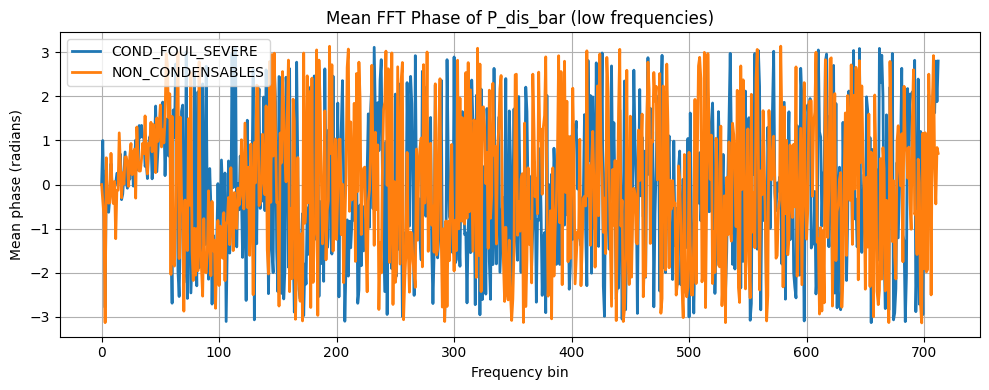

In [41]:
from scipy.signal import correlate
from numpy.fft import fft, ifft, rfft, rfftfreq

FAULT_LABELS = {
    "NORMAL": 0,
    "COND_FOUL_MILD": 1,
    "COND_FOUL_SEVERE": 2,
    "EVAP_FAN_DEG": 3,
    "EVAP_FAN_FAIL": 4,
    "UNDERCHARGE_MILD": 5,
    "UNDERCHARGE_SEVERE": 6,
    "OVERCHARGE": 7,
    "SENSOR_DRIFT_PLUS": 8,
    "SENSOR_DRIFT_MINUS": 9,
    "COMP_INEFFICIENCY": 10,
    "NON_CONDENSABLES": 11,
    "UNDERCHARGE_AND_COND_FOUL": 12
}

def id_to_fault_name(fid):
    for name, idx in FAULT_LABELS.items():
        if idx == fid:
            return name
    return "UNKNOWN"


df_plot = df[df['fault_id'].isin([2, 11])].copy()
df_plot['fault_name'] = df_plot['fault_id'].apply(id_to_fault_name)


key_features = [
    'P_dis_bar',
    'T_cond_approach',
    'P_dis_volatility',
    'P_dis_error',
    'T_subcooling_approx', 
    'P_ratio',
    'Power_per_diff',
    'Q_est',
    'Sensor_error',
    'T_cab_grad',
    'P_suc_rate',
    'Eff_vol',
    'P_suc_norm', 
    'Pdis_instability_20',
    'cond_approach_std_20',
    'cop_degradation', 
    'specific_work', 
    'T_spread',
    'Power_to_Pratio', 
    'T_lift'
]


def plot_feature(feature, step=20):
    plt.figure(figsize=(10, 4))

    for fault in ['COND_FOUL_SEVERE', 'NON_CONDENSABLES']:
        d_fault = df_plot[df_plot['fault_name'] == fault]

        # Último run
        last_run_id = d_fault['run_id'].max()-6
        run = d_fault[d_fault['run_id'] == last_run_id]

        # Cuantiles por tiempo
        grouped = (
            d_fault
            .groupby('time_min')[feature]
            .quantile([0.25, 0.75])
            .unstack()
            .reset_index()
        )

        # Q25–Q75
        plt.fill_between(
            grouped['time_min'][::step],
            grouped[0.25][::step],
            grouped[0.75][::step],
            alpha=0.25,
            label=f"{fault} Q25–Q75"
        )

        # Último run
        plt.plot(
            run['time_min'].values[::step],
            run[feature].values[::step],
            linewidth=2,
            label=f"{fault} (last run)"
        )

        #Mean over todos los runs
        plt.plot(
            grouped['time_min'][::step],
            d_fault.groupby('time_min')[feature].mean().values[::step],
            linestyle='--',
            linewidth=2,
            label=f"{fault} Mean (all runs)"
        )

    plt.title(feature)
    plt.xlabel("Time (minutes)")
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

for feature in key_features:
    plot_feature(feature)


mean_values = (
    df_plot
    .groupby('fault_name')[key_features]
    .mean()
)

q25_q75 = (
    df_plot
    .groupby('fault_name')[key_features]
    .quantile([0.25, 0.75])
)

print("\nMean values:")
print(mean_values)

print("\nQuantiles 25 and 75:")
print(q25_q75)


#Fourier transform P_dis_bar for COND_FOUL_SEVERE and NON_CONDENSABLES

def fourier_transform(signal):
    return np.fft.rfft(signal)

print("\nFourier transform of P_dis_bar (last run):")

for fault in ['COND_FOUL_SEVERE', 'NON_CONDENSABLES']:
    d = df_plot[df_plot['fault_name'] == fault]
    last_run_id = d['run_id'].max()
    run = d[d['run_id'] == last_run_id]

    fft_signal = fourier_transform(run['P_dis_bar'])
    print(f"{fault}: FFT shape = {fft_signal.shape}")
    

#Plot FFT magnitude

    plt.figure(figsize=(10, 4))
    plt.plot(np.abs(fft_signal))
    plt.title(f"FFT Magnitude of P_dis_bar - {fault} (last run)")
    plt.xlabel("Frequency Bin")
    plt.ylabel("Magnitude")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

#Plot mean FFT magnitude over all runs
 
    all_runs = d['run_id'].unique()
    fft_magnitudes = []
    for run_id in all_runs:
        run_data = d[d['run_id'] == run_id]
        fft_run = fourier_transform(run_data['P_dis_bar'])
        fft_magnitudes.append(np.abs(fft_run))
    mean_fft_magnitude = np.mean(fft_magnitudes, axis=0)
    plt.figure(figsize=(10, 4))
    plt.plot(mean_fft_magnitude)
    plt.title(f"Mean FFT Magnitude of P_dis_bar - {fault} (all runs)")
    plt.xlabel("Frequency Bin")
    plt.ylabel("Mean Magnitude")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

def circular_mean(phases, axis=0):
    return np.angle(np.mean(np.exp(1j * phases), axis=axis))


#Mean phase of FFT in P_dis_bar between COND_FOUL_SEVERE and NON_CONDENSABLES

plt.figure(figsize=(10, 4))

for fault in ['COND_FOUL_SEVERE', 'NON_CONDENSABLES']:

    d = df_plot[df_plot['fault_name'] == fault]
    all_runs = d['run_id'].unique()

    phase_list = []

    for run_id in all_runs:
        run = d[d['run_id'] == run_id]

        if len(run) < 10:
            continue  # safety

        fft_run = fourier_transform(run['P_dis_bar'])
        phase_run = np.angle(fft_run)

        phase_list.append(phase_run)

    # Stack safely
    phase_array = np.vstack(phase_list)

    # Circular mean phase
    mean_phase = circular_mean(phase_array, axis=0)

    # Plot only low-frequency part (physically meaningful)
    n_freq = len(mean_phase)
    max_bin = int(n_freq)  # first 10%

    plt.plot(
        mean_phase[:max_bin],
        label=fault,
        linewidth=2
    )

plt.title("Mean FFT Phase of P_dis_bar (low frequencies)")
plt.xlabel("Frequency bin")
plt.ylabel("Mean phase (radians)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [ ]:

from sklearn.utils.class_weight import compute_class_weight

def compute_sample_weights(df_phys, target_col='fault_numeric'):
    classes = np.unique(df_phys[target_col])
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=df_phys[target_col]
    )
    class_weight_dict = dict(zip(classes, class_weights))
    
    # .copy() ensures the array is mutable and avoids the ValueError
    weights = df_phys[target_col].map(class_weight_dict).values.copy()

    p_dis_threshold = df_phys["mean_P_dis_bar"].quantile(0.90)
    early_error_threshold = df_phys["early_P_dis_error"].quantile(0.90)

    # Apply multipliers
    weights *= np.where(df_phys["early_P_dis_error"] > early_error_threshold, 1.5, 1.0)
    weights *= np.where(df_phys["mean_P_dis_bar"] > p_dis_threshold, 1.2, 1.0)
    
    return weights

def physics_indicators(df):
    phys = pd.DataFrame(index=df.index)
    
    # We use the existing features you created in extract_physics_features
    # Discharge Pressure startup spike (First 100 points of the run)
    phys['early_P_dis_error'] = df.groupby('run_id')['P_dis_error'].transform(lambda x: x.iloc[:100].mean())
    phys['mean_P_dis_bar'] = df.groupby('run_id')['P_dis_bar'].transform('mean')
    
    
    return phys

physics_feats = physics_indicators(df)
# Avoid duplicating columns if they already exist in df
cols_to_add = physics_feats.columns.difference(df.columns)
df_phys = df.join(physics_feats[cols_to_add])


In [ ]:
def inject_test_noise_refrigeracion(X_test_df, noise_level=0.10, include_spikes=True):
    """
    Añade ruido gaussiano (fluctuación de señal) y picos de error (spikes) 
    al set de test de refrigeración para simular sensores reales de planta.
    Garantiza la reproducibilidad usando una semilla aleatoria local.
    """
    X_noisy = X_test_df.copy()
    np.random.seed(42) # Semilla fija para reproducibilidad del Stress Test
    
    for col in X_noisy.columns:
        # Evitamos meter ruido a las columnas binarias/indicadores de la nevera
        if col in ['defrost_on', 'door_open']:
            continue
            
        # 1. Ruido Gaussiano
        scale = X_noisy[col].std() * noise_level
        if scale > 0:
            X_noisy[col] += np.random.normal(0, scale, X_noisy.shape[0])
            
        # 2. Spikes Aleatorios (1 de cada 100 lecturas falla por interferencia física)
        if include_spikes:
            mask = np.random.rand(len(X_noisy)) < 0.01
            if mask.any():
                X_noisy.loc[mask, col] *= np.random.choice([0.8, 1.2]) 
                
    return X_noisy

In [ ]:
from sklearn.model_selection import train_test_split
STRESS_TEST_ACTIVE = False  # Activar para añadir ruido al set de test
NOISE_LEVEL = 0.10
INCLUDE_SPIKES = True

target_mapping = {
    "NORMAL": 0, "COND_FOUL_MILD": 1, "COND_FOUL_SEVERE": 2,
    "EVAP_FAN_DEG": 3, "EVAP_FAN_FAIL": 4, "UNDERCHARGE_MILD": 5,
    "UNDERCHARGE_SEVERE": 6, "OVERCHARGE": 7, "SENSOR_DRIFT_PLUS": 8,
    "SENSOR_DRIFT_MINUS": 9, "COMP_INEFFICIENCY": 10, "NON_CONDENSABLES": 11,
    "UNDERCHARGE_AND_COND_FOUL": 12
}
df_phys['fault_numeric'] = df_phys['fault'].map(target_mapping)

run_labels = df_phys.groupby('run_id')['fault_numeric'].first()
unique_runs = run_labels.index

train_runs, test_runs = train_test_split(
    unique_runs, test_size=0.2, random_state=42, stratify=run_labels 
)

train_df = df_phys[df_phys['run_id'].isin(train_runs)].copy()
test_df  = df_phys[df_phys['run_id'].isin(test_runs)].copy()

target_column = 'fault_numeric'
drop_cols = [target_column, 'fault', 'run_id', 'fault_id', 'time_min', 'T_cond_sat', 'T_cab_meas', 'P_suc_bar']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_column]
X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_column]

if STRESS_TEST_ACTIVE:
    print(f"⚠️ STRESS TEST ACTIVADO: Inyectando {NOISE_LEVEL*100}% de ruido en el set de Test.")
    X_test_processed = inject_test_noise_refrigeracion(X_test, noise_level=NOISE_LEVEL, include_spikes=INCLUDE_SPIKES)
    test_df[X_test.columns] = X_test_processed
else:
    print("ℹ️ Evaluando con datos limpios.")
    X_test_processed = X_test.copy()

sample_weights = compute_sample_weights(train_df)

binary_cols = ['defrost_on', 'door_open']
numerical_cols = [c for c in X_train.columns if c not in binary_cols]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test_processed.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_processed[numerical_cols])

Mapped fault labels: {'NORMAL': 0, 'COND_FOUL_MILD': 1, 'COND_FOUL_SEVERE': 2, 'EVAP_FAN_DEG': 3, 'EVAP_FAN_FAIL': 4, 'UNDERCHARGE_MILD': 5, 'UNDERCHARGE_SEVERE': 6, 'OVERCHARGE': 7, 'SENSOR_DRIFT_PLUS': 8, 'SENSOR_DRIFT_MINUS': 9, 'COMP_INEFFICIENCY': 10, 'NON_CONDENSABLES': 11, 'UNDERCHARGE_AND_COND_FOUL': 12}
Training samples: 1482000 | Testing samples: 370500
Total features: 67


In [44]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Ya no repetimos el split. Usamos X_train_scaled y y_train de la Celda 8.

# 2. Ajustamos la malla de parámetros para velocidad
param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [15, 20, 25],  # Limitado: Evita que el modelo pese GBs y tarde horas
    'min_samples_leaf': [20, 50], # Aumentado: Ayuda a generalizar y entrena más rápido
    'max_features': ['sqrt']
}

# 3. Configuración de CV eficiente
# Reducimos n_iter a 3 o 4 para una búsqueda rápida inicial
cv = StratifiedGroupKFold(n_splits=3)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, 
        n_jobs=-1,      # Usa todos los núcleos
        verbose=1       
    ),
    param_distributions=param_grid,
    n_iter=3,           
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,          
    verbose=1
)

# Entrenamiento
# IMPORTANTE: Asegúrate de que 'groups' coincida con las filas de X_train_scaled
groups_train = train_df['run_id']

print("Iniciando búsqueda de hiperparámetros...")
rf_search.fit(
    X_train_scaled, 
    y_train, 
    groups=groups_train, 
    sample_weight=sample_weights
)

rf_classifier = rf_search.best_estimator_
print(f"Mejores Parámetros: {rf_search.best_params_}")

# Guardado
#joblib.dump(rf_classifier, 'rf_fridge_fault_model_optimized.pkl')

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.3min


Mejores Parámetros: {'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 20}


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.7min finished


In [45]:
joblib.dump(rf_classifier, 'rf_fridge_fault_model_optimized.pkl')

['rf_fridge_fault_model_optimized.pkl']

In [46]:

train_run_ids = df.loc[X_train.index, 'run_id']
test_run_ids  = df.loc[X_test.index, 'run_id']

# Calculate Early P_dis Error (First 100 points per run)
# This distinguishes Non-Condensables by their startup pressure spike
X_train['early_P_dis_error'] = df.loc[X_train.index].groupby(train_run_ids)['P_dis_error'].transform(lambda x: x.iloc[:100].mean())
X_test['early_P_dis_error']  = df.loc[X_test.index].groupby(test_run_ids)['P_dis_error'].transform(lambda x: x.iloc[:100].mean())

# Mean P_dis (Average over the whole run)
X_train['mean_P_dis_bar'] = df.loc[X_train.index].groupby(train_run_ids)['P_dis_bar'].transform('mean')
X_test['mean_P_dis_bar']  = df.loc[X_test.index].groupby(test_run_ids)['P_dis_bar'].transform('mean')

# Condenser Approach (T_cond - T_amb), to detect fouling
X_train['T_cond_approach'] = df.loc[X_train.index, 'T_cond_sat'] - df.loc[X_train.index, 'T_amb']
X_test['T_cond_approach']  = df.loc[X_test.index, 'T_cond_sat'] - df.loc[X_test.index, 'T_amb']


PHYS_COLS = ["early_P_dis_error", "mean_P_dis_bar", "T_cond_approach"]
X_train_phys = X_train[PHYS_COLS]
X_test_phys  = X_test[PHYS_COLS]

#THRESHOLDS

def quantile_threshold(df, y, feature, label_str, q):
    
    label_id = target_mapping[label_str]
 
    val = df.loc[y == label_id, feature].quantile(q)
    return val

THRESHOLDS = {
    "noncond": {
        "P_dis_error_early": {
          
            "low": quantile_threshold(X_train, y_train, "early_P_dis_error", "NON_CONDENSABLES", 0.1)
        },
        "P_dis_mean": {
            "low": quantile_threshold(X_train, y_train, "mean_P_dis_bar", "NON_CONDENSABLES", 0.1)
        }
    },
    "cond_foul": {
        "T_cond_approach": {
            
            "high": quantile_threshold(X_train, y_train, "T_cond_approach", "COND_FOUL_SEVERE", 0.9) # High quantile to catch severe fouling
        }
    }
}

# ---VERIFICATION ---
print("Calculated Thresholds:")
print(f"NC Early Error Low: {THRESHOLDS['noncond']['P_dis_error_early']['low']:.4f}")
print(f"NC Mean P_dis Low:   {THRESHOLDS['noncond']['P_dis_mean']['low']:.4f}")
print(f"CF Approach High:    {THRESHOLDS['cond_foul']['T_cond_approach']['high']:.4f}")

Calculated Thresholds:
NC Early Error Low: -0.2640
NC Mean P_dis Low:   7.0978
CF Approach High:    10.5702


In [47]:
#NEUROSYMBOLIC REASONING

inverse_target_mapping = {v: k for k, v in target_mapping.items()}
CLASS_INDEX = {inverse_target_mapping[label]: i for i, label in enumerate(rf_classifier.classes_)}

def neurosymbolic_reasoning_fast(X_phys_df, model, X_scaled, T, mapping):
    y_pred_original = model.predict(X_scaled)
    y_pred_final = y_pred_original.copy()
    ids = {name: mapping[name] for name in mapping}

    # --- REGLAS FÍSICAS (Correcciones puntuales) ---
    # Regla 1: Sensor Drift
    y_pred_final[X_phys_df['T_cab_meas_diff'] > 2.0]  = ids["SENSOR_DRIFT_MINUS"]
    y_pred_final[X_phys_df['T_cab_meas_diff'] < -2.0] = ids["SENSOR_DRIFT_PLUS"]

    # Regla 2: Undercharge
    uc_p_gate = X_phys_df['P_suc_bar'].quantile(0.1)
    y_pred_final[(X_phys_df['P_suc_bar'] < uc_p_gate) & (X_phys_df['SH_K'] > 15)] = ids["UNDERCHARGE_SEVERE"]

    # Regla 3: Inefficiency
    y_pred_final[(X_phys_df['Eff_vol'] < 0.6) & (y_pred_original == ids["NORMAL"])] = ids["COMP_INEFFICIENCY"]

    # --- REGLA 4: EL SWAP SELECTIVO (Basado en física) ---
    nc_phys = (X_phys_df["early_P_dis_error"] > T["noncond"]["P_dis_error_early"]["low"]) & \
              (X_phys_df["T_cond_approach"] < T["cond_foul"]["T_cond_approach"]["high"] * 0.9)
    
    cf_phys = (X_phys_df["T_cond_approach"] > T["cond_foul"]["T_cond_approach"]["high"]) & \
              (X_phys_df["early_P_dis_error"] < T["noncond"]["P_dis_error_early"]["low"] * 1.2)

    in_scope = (y_pred_original == ids["NON_CONDENSABLES"]) | (y_pred_original == ids["COND_FOUL_SEVERE"])
    
    # Aplicamos primero el swap basado en evidencia física
    y_pred_final[in_scope & (y_pred_original == ids["NON_CONDENSABLES"]) & cf_phys] = ids["COND_FOUL_SEVERE"]
    y_pred_final[in_scope & (y_pred_original == ids["COND_FOUL_SEVERE"]) & nc_phys] = ids["NON_CONDENSABLES"]

    # --- LÓGICA DE SWAP TOTAL (Si decides que el modelo siempre está invertido) ---
    # Nota: Si el swap selectivo de arriba ya funcionó, esto intercambiará TODO de nuevo.
    # Úsalo solo si estás seguro de que el RF invierte las clases 2 y 11 siempre.
    temp_nc_mask = (y_pred_final == ids["NON_CONDENSABLES"])
    temp_cf_mask = (y_pred_final == ids["COND_FOUL_SEVERE"])
    
    y_pred_final[temp_nc_mask] = ids["COND_FOUL_SEVERE"]
    y_pred_final[temp_cf_mask] = ids["NON_CONDENSABLES"]

    return y_pred_final

# Ejecución
y_pred_ns = neurosymbolic_reasoning_fast(test_df, rf_classifier, X_test_scaled, THRESHOLDS, target_mapping)


nc_id = target_mapping["NON_CONDENSABLES"]
cf_id = target_mapping["COND_FOUL_SEVERE"]
print(f"After NC: {(y_pred_ns == nc_id).sum()} | After CF: {(y_pred_ns == cf_id).sum()}")

initial_preds = rf_classifier.predict(X_test_scaled)
# Final assignment for evaluation
y_pred = initial_preds

[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.8s
[Parallel(n_jobs=32)]: Done 200 out of 200 | elapsed:    1.2s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


After NC: 23317 | After CF: 33503


[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.8s
[Parallel(n_jobs=32)]: Done 200 out of 200 | elapsed:    1.2s finished


In [48]:
from sklearn.metrics import classification_report

def apply_run_voting(df, y_pred):
    df_temp = df.copy()
    df_temp['y_pred'] = y_pred
    
    # Encontramos la predicción más frecuente para cada ciclo de funcionamiento
    run_votes = df_temp.groupby('run_id')['y_pred'].transform(
        lambda x: x.value_counts().idxmax()
    )
    
    return run_votes.values

# Aplicar el suavizado por voto
y_pred_final_voted = apply_run_voting(test_df, y_pred_ns)

print("--- 1. MODELO PURO (RF) ---")
y_pred_pure = rf_classifier.predict(X_test_scaled)
# Definimos exactamente qué queremos ver para evitar que sklearn se confunda
selected_ids = [2, 11]
selected_names = [inverse_target_mapping[2], inverse_target_mapping[11]]

print("--- 1. MODELO PURO (RF) ---")
print(classification_report(y_test, y_pred_pure, labels=selected_ids, target_names=selected_names))

print("--- 2. MODELO NEUROSIMBÓLICO (DNL) ---")
print(classification_report(y_test, y_pred_ns, labels=selected_ids, target_names=selected_names))

print("--- 3. MODELO FINAL (DNL + VOTO) ---")
print(classification_report(y_test, y_pred_final_voted, labels=selected_ids, target_names=selected_names))

[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


--- 1. MODELO PURO (RF) ---


[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.8s
[Parallel(n_jobs=32)]: Done 200 out of 200 | elapsed:    1.1s finished


--- 1. MODELO PURO (RF) ---
                  precision    recall  f1-score   support

COND_FOUL_SEVERE       0.38      0.42      0.40     28500
NON_CONDENSABLES       0.34      0.30      0.32     28500

       micro avg       0.36      0.36      0.36     57000
       macro avg       0.36      0.36      0.36     57000
    weighted avg       0.36      0.36      0.36     57000

--- 2. MODELO NEUROSIMBÓLICO (DNL) ---
                  precision    recall  f1-score   support

COND_FOUL_SEVERE       0.63      0.74      0.68     28500
NON_CONDENSABLES       0.69      0.56      0.62     28500

       micro avg       0.65      0.65      0.65     57000
       macro avg       0.66      0.65      0.65     57000
    weighted avg       0.66      0.65      0.65     57000

--- 3. MODELO FINAL (DNL + VOTO) ---
                  precision    recall  f1-score   support

COND_FOUL_SEVERE       0.65      0.75      0.70     28500
NON_CONDENSABLES       0.71      0.60      0.65     28500

       micro avg  

MODEL EVALUATION

--- CLASSIFICATION REPORT: MODELO PURO (RF) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     28500
           1       0.98      0.98      0.98     28500
           2       0.38      0.42      0.40     28500
           3       1.00      1.00      1.00     28500
           4       1.00      1.00      1.00     28500
           5       1.00      1.00      1.00     28500
           6       1.00      1.00      1.00     28500
           7       1.00      1.00      1.00     28500
           8       1.00      1.00      1.00     28500
           9       1.00      1.00      1.00     28500
          10       1.00      1.00      1.00     28500
          11       0.34      0.30      0.32     28500
          12       1.00      1.00      1.00     28500

    accuracy                           0.90    370500
   macro avg       0.90      0.90      0.90    370500
weighted avg       0.90      0.90      0.90    370500



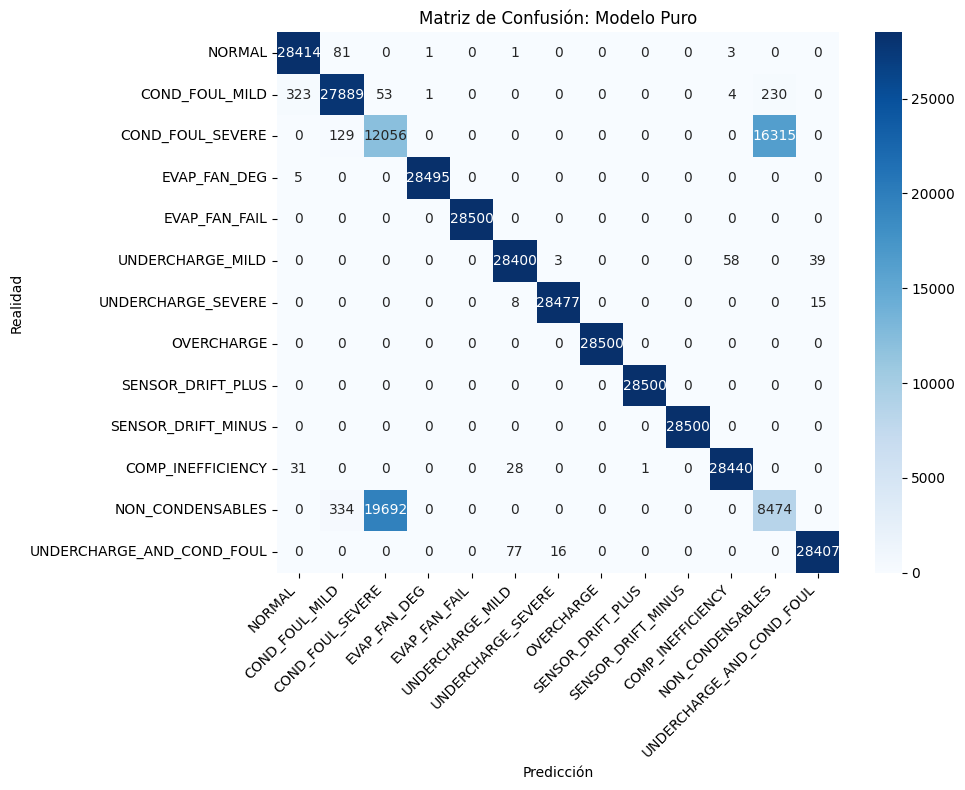

--- CLASSIFICATION REPORT: NEUROSIMBÓLICO ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     28500
           1       0.98      0.98      0.98     28500
           2       0.63      0.74      0.68     28500
           3       1.00      1.00      1.00     28500
           4       1.00      1.00      1.00     28500
           5       1.00      1.00      1.00     28500
           6       1.00      1.00      1.00     28500
           7       1.00      1.00      1.00     28500
           8       1.00      1.00      1.00     28500
           9       1.00      1.00      1.00     28500
          10       1.00      1.00      1.00     28500
          11       0.69      0.56      0.62     28500
          12       1.00      1.00      1.00     28500

    accuracy                           0.94    370500
   macro avg       0.94      0.94      0.94    370500
weighted avg       0.94      0.94      0.94    370500



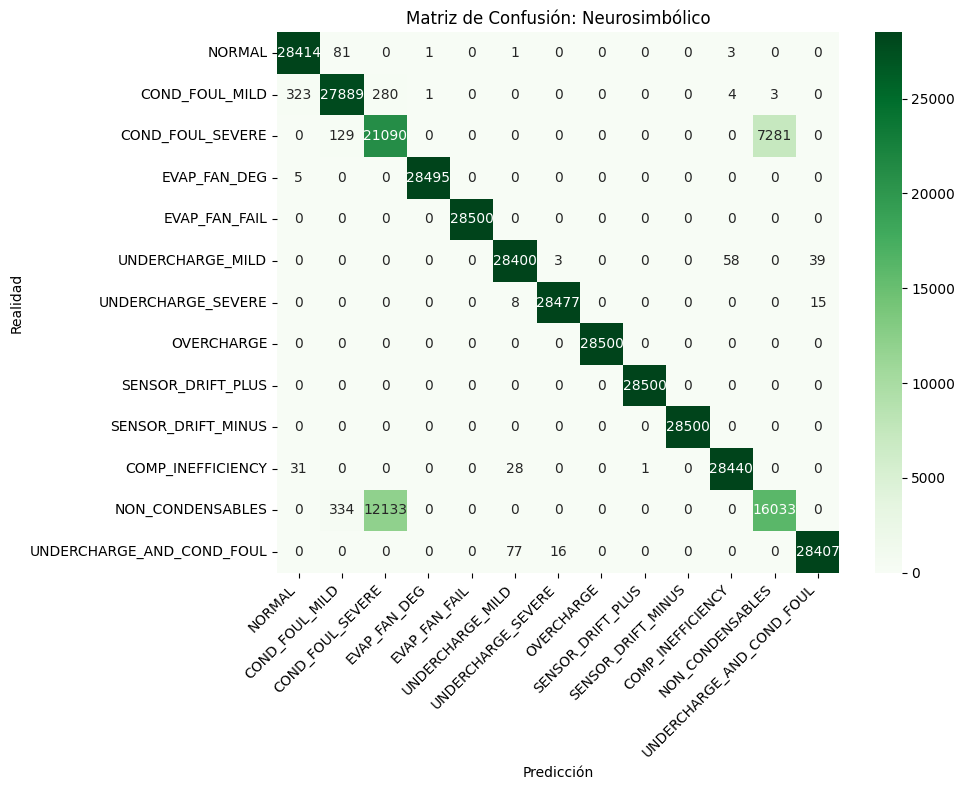

--- CLASSIFICATION REPORT: FINAL (VOTO POR RUN) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28500
           1       1.00      1.00      1.00     28500
           2       0.65      0.75      0.70     28500
           3       1.00      1.00      1.00     28500
           4       1.00      1.00      1.00     28500
           5       1.00      1.00      1.00     28500
           6       1.00      1.00      1.00     28500
           7       1.00      1.00      1.00     28500
           8       1.00      1.00      1.00     28500
           9       1.00      1.00      1.00     28500
          10       1.00      1.00      1.00     28500
          11       0.71      0.60      0.65     28500
          12       1.00      1.00      1.00     28500

    accuracy                           0.95    370500
   macro avg       0.95      0.95      0.95    370500
weighted avg       0.95      0.95      0.95    370500



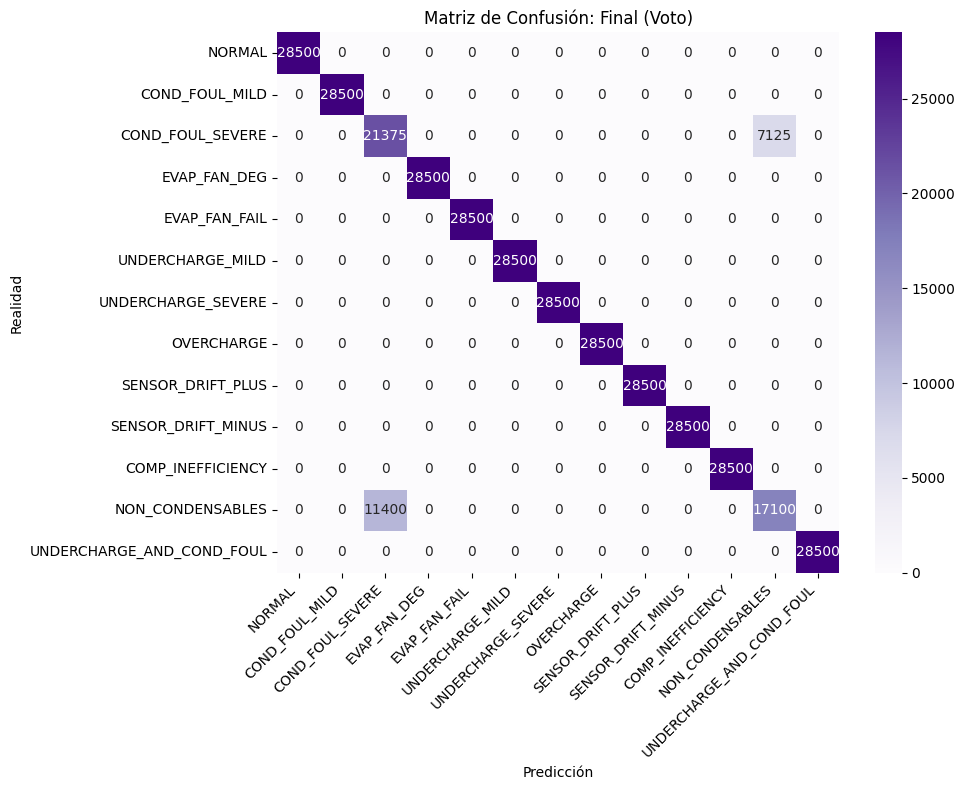

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Definimos una función para no repetir código y asegurar que los ticks sean perfectos
def plot_clean_confusion_matrix(y_true, y_pred, title, cmap):
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    
    # seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True)
    
    # AJUSTE DE TICKS: Centrados y con los nombres correctos
    tick_marks = np.arange(len(target_mapping)) + 0.5
    plt.xticks(tick_marks, target_mapping.keys(), rotation=45, ha='right')
    plt.yticks(tick_marks, target_mapping.keys(), rotation=0)
    
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.tight_layout()
    plt.show()

# EVALUACIÓN: MODELO PURO
print('--- CLASSIFICATION REPORT: MODELO PURO (RF) ---')
print(classification_report(y_test, initial_preds))
plot_clean_confusion_matrix(y_test, initial_preds, 'Matriz de Confusión: Modelo Puro', 'Blues')

#  EVALUACIÓN: NEUROSIMBÓLICO
print('--- CLASSIFICATION REPORT: NEUROSIMBÓLICO ---')
print(classification_report(y_test, y_pred_ns))
plot_clean_confusion_matrix(y_test, y_pred_ns, 'Matriz de Confusión: Neurosimbólico', 'Greens')

#  EVALUACIÓN: FINAL (CON VOTO) 
# Asegúrate de haber ejecutado el bloque del voto antes de esto
print('--- CLASSIFICATION REPORT: FINAL (VOTO POR RUN) ---')
print(classification_report(y_test,  y_pred_final_voted))
plot_clean_confusion_matrix(y_test,  y_pred_final_voted, 'Matriz de Confusión: Final (Voto)', 'Purples')

fault_id = 2 (COND_FOUL_SEVERE) and fault_id = 11 (NON_CONDENSABLES) are being confused, and both are high-pressure–side faults. The model struggles because many raw features overlap.

↑ Discharge pressure (P_dis_bar)

↑ Condenser saturation temperature (T_cond_sat)

↓ COP

↑ Compressor power (P_comp_W)